<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

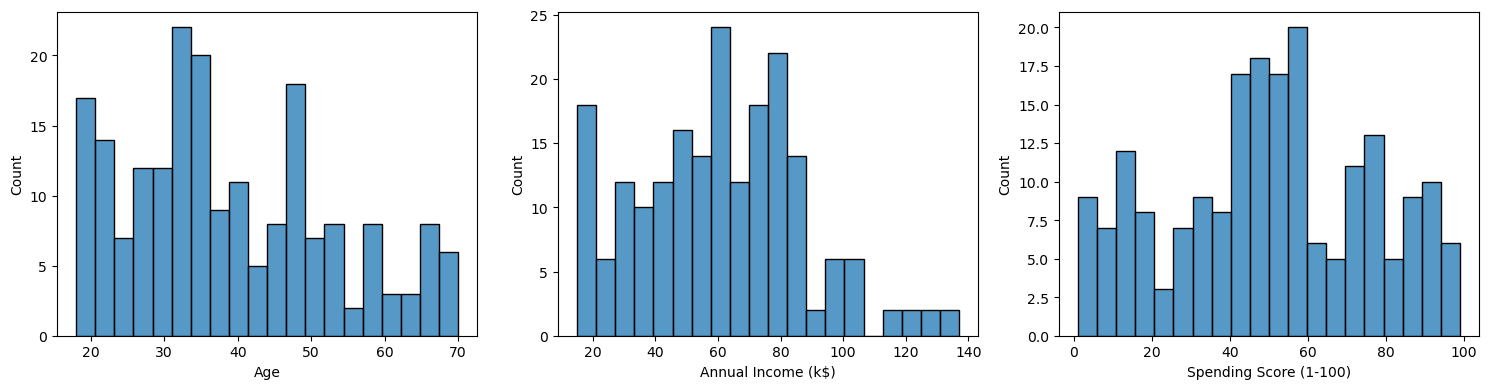

<Axes: xlabel='Genre', ylabel='count'>

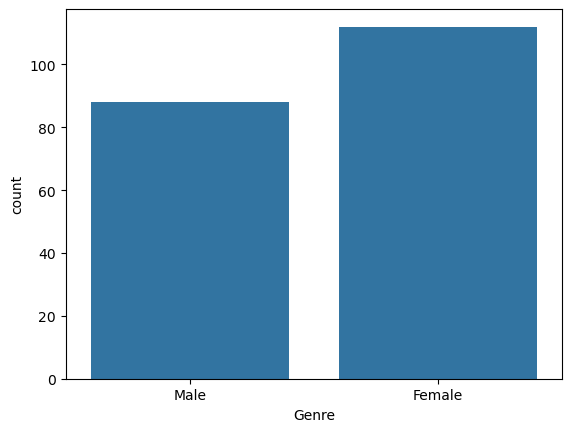

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'D:\InternshipTasksDatasets\Mall Customer dataset\Mall_Customers.csv')

# Check basic info
print(df.info())
print(df.describe())

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], bins=20, ax=axes[0])
sns.histplot(df['Annual Income (k$)'], bins=20, ax=axes[1])
sns.histplot(df['Spending Score (1-100)'], bins=20, ax=axes[2])
plt.tight_layout()
plt.show()

# Gender distribution
sns.countplot(data=df, x='Genre')

D:\Anacondafiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anacondafiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anacondafiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anacondafiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

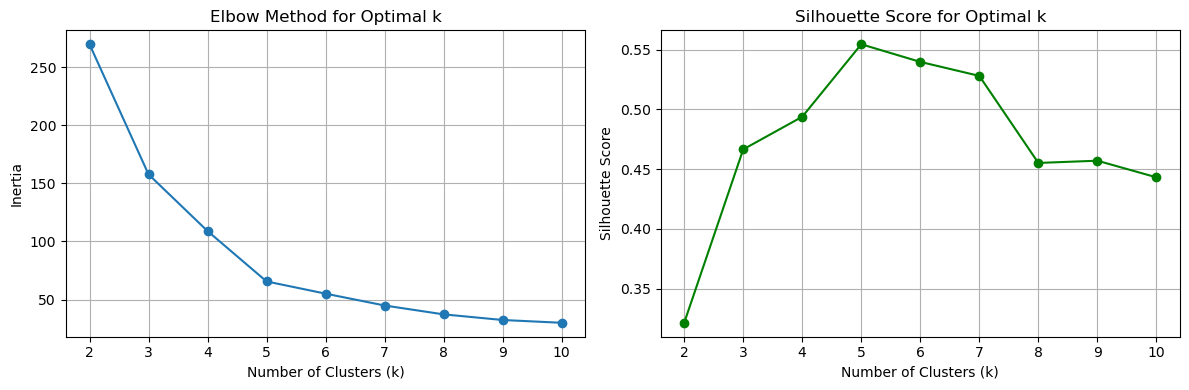


Cluster Centers (Original Scale):
           Annual Income (k$)  Spending Score (1-100)
Cluster 0           55.296296               49.518519
Cluster 1           86.538462               82.128205
Cluster 2           25.727273               79.363636
Cluster 3           88.200000               17.114286
Cluster 4           26.304348               20.913043


D:\Anacondafiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k using elbow method
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(2, 11), inertias, marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

ax2.plot(range(2, 11), silhouette_scores, marker='o', color='green')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Based on elbow method, k=5 is optimal
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Add cluster centers (in original scale)
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster Centers (Original Scale):")
print(pd.DataFrame(cluster_centers, 
                   columns=['Annual Income (k$)', 'Spending Score (1-100)'],
                   index=[f'Cluster {i}' for i in range(optimal_k)]))

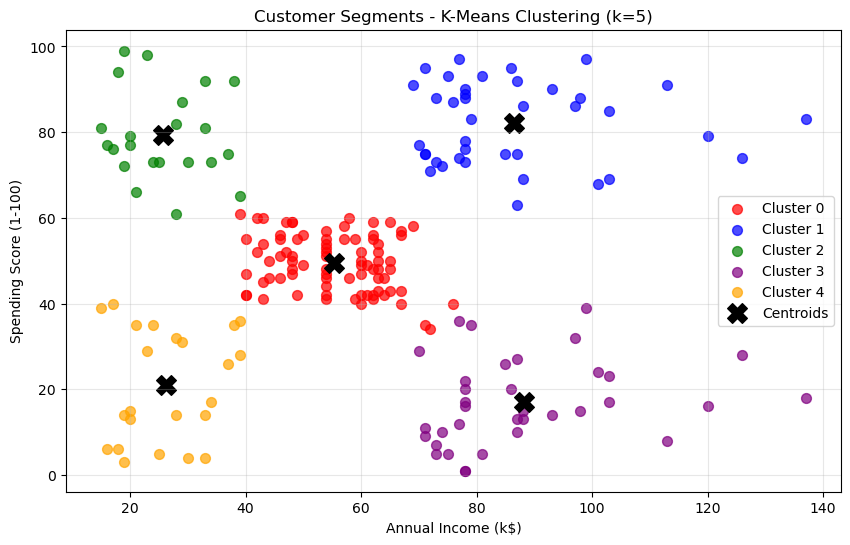

In [4]:
# Plot clusters in original feature space
plt.figure(figsize=(10, 6))

# Define color palette
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'], 
                cluster_data['Spending Score (1-100)'],
                c=colors[i], 
                label=f'Cluster {i}',
                alpha=0.7,
                s=50)

# Plot cluster centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments - K-Means Clustering (k=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

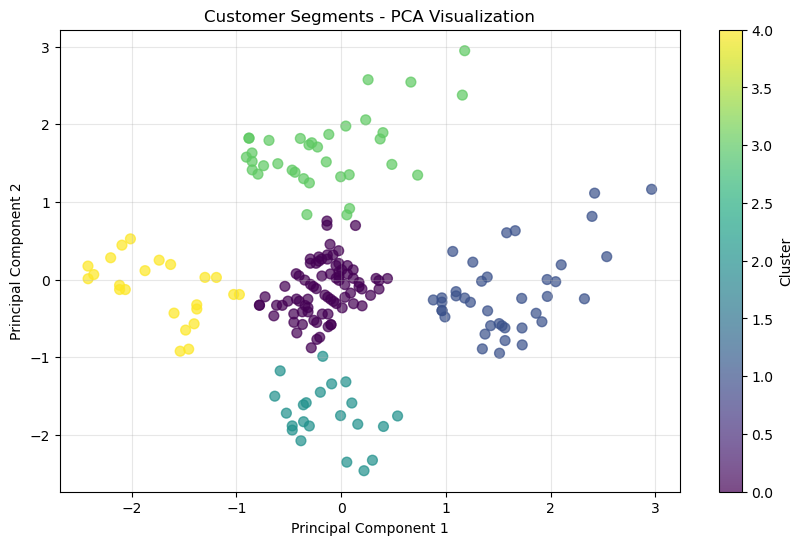

In [5]:
from sklearn.decomposition import PCA

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df['Cluster'], cmap='viridis', 
                      alpha=0.7, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments - PCA Visualization')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Analyze each cluster
cluster_analysis = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(2)

cluster_analysis.columns = ['Avg Age', 'Avg Income', 'Avg Spending Score', 'Customer Count']
print("\nCluster Analysis:")
print(cluster_analysis)

# Count customers per cluster
print("\nCustomer Distribution:")
print(df['Cluster'].value_counts().sort_index())


Cluster Analysis:
         Avg Age  Avg Income  Avg Spending Score  Customer Count
Cluster                                                         
0          42.72       55.30               49.52              81
1          32.69       86.54               82.13              39
2          25.27       25.73               79.36              22
3          41.11       88.20               17.11              35
4          45.22       26.30               20.91              23

Customer Distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [7]:
# Create a summary table for marketing strategies
marketing_strategies = {
    'Cluster': [],
    'Segment Name': [],
    'Characteristics': [],
    'Marketing Strategy': []
}

# Analyze each cluster to suggest strategies
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    
    # Determine segment type based on income and spending
    if avg_income > 70 and avg_spending > 60:
        segment_name = "High Income, High Spending"
        characteristics = "Affluent customers who spend generously"
        strategy = "Premium loyalty programs, exclusive offers, new product launches"
    elif avg_income > 70 and avg_spending <= 60:
        segment_name = "High Income, Low Spending"
        characteristics = "Affluent but conservative spenders"
        strategy = "Value-based messaging, bundle deals, education on product benefits"
    elif avg_income <= 70 and avg_spending > 60:
        segment_name = "Low Income, High Spending"
        characteristics = "Budget-conscious but enthusiastic shoppers"
        strategy = "Installment plans, discounts, seasonal sales"
    elif avg_income <= 70 and avg_spending <= 40:
        segment_name = "Low Income, Low Spending"
        characteristics = "Cautious customers"
        strategy = "Basic products, essential items, build trust gradually"
    else:
        segment_name = "Medium Income, Medium Spending"
        characteristics = "Average customers"
        strategy = "Retention campaigns, cross-selling, consistent engagement"
    
    marketing_strategies['Cluster'].append(cluster_id)
    marketing_strategies['Segment Name'].append(segment_name)
    marketing_strategies['Characteristics'].append(characteristics)
    marketing_strategies['Marketing Strategy'].append(strategy)

# Display marketing strategies
strategies_df = pd.DataFrame(marketing_strategies)
print("\n" + "="*80)
print("MARKETING STRATEGIES BY SEGMENT")
print("="*80)
print(strategies_df.to_string(index=False))


MARKETING STRATEGIES BY SEGMENT
 Cluster                   Segment Name                            Characteristics                                                 Marketing Strategy
       0 Medium Income, Medium Spending                          Average customers          Retention campaigns, cross-selling, consistent engagement
       1     High Income, High Spending    Affluent customers who spend generously   Premium loyalty programs, exclusive offers, new product launches
       2      Low Income, High Spending Budget-conscious but enthusiastic shoppers                       Installment plans, discounts, seasonal sales
       3      High Income, Low Spending         Affluent but conservative spenders Value-based messaging, bundle deals, education on product benefits
       4       Low Income, Low Spending                         Cautious customers             Basic products, essential items, build trust gradually
